In [1]:
import sys; sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    classification_report, roc_curve, auc,
    accuracy_score, precision_score, confusion_matrix
)

(
    X_train, X_test,
    X_train_sc, X_test_sc,
    y_train_c, y_test_c,
    feature_names
) = joblib.load("../data/processed/splits.pkl")

In [11]:
rf = joblib.load("models/rf_model.pkl")
lr = joblib.load("models/lr_model.pkl")

print("Modelos cargados correctamente")

Modelos cargados correctamente


In [14]:
y_pred_rf = rf.predict(X_test_sc)
y_pred_lr = lr.predict(X_test_sc)

y_proba_rf = rf.predict_proba(X_test_sc)[:, 1]
y_proba_lr = lr.predict_proba(X_test_sc)[:, 1]

In [15]:
print("=== RANDOM FOREST ===")
print(classification_report(y_test_c, y_pred_rf, target_names=["No Viral","Viral"]))
print("Accuracy:", accuracy_score(y_test_c, y_pred_rf))
print("Precision:", precision_score(y_test_c, y_pred_rf))

print("\n=== LOGISTIC REGRESSION ===")
print(classification_report(y_test_c, y_pred_lr, target_names=["No Viral","Viral"]))
print("Accuracy:", accuracy_score(y_test_c, y_pred_lr))
print("Precision:", precision_score(y_test_c, y_pred_lr))

=== RANDOM FOREST ===
              precision    recall  f1-score   support

    No Viral       0.80      0.99      0.88      3076
       Viral       0.84      0.18      0.30       937

    accuracy                           0.80      4013
   macro avg       0.82      0.59      0.59      4013
weighted avg       0.81      0.80      0.75      4013

Accuracy: 0.8008970844754548
Precision: 0.8415841584158416

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

    No Viral       0.77      1.00      0.87      3076
       Viral       0.67      0.01      0.02       937

    accuracy                           0.77      4013
   macro avg       0.72      0.50      0.44      4013
weighted avg       0.74      0.77      0.67      4013

Accuracy: 0.7675056067779716
Precision: 0.6666666666666666


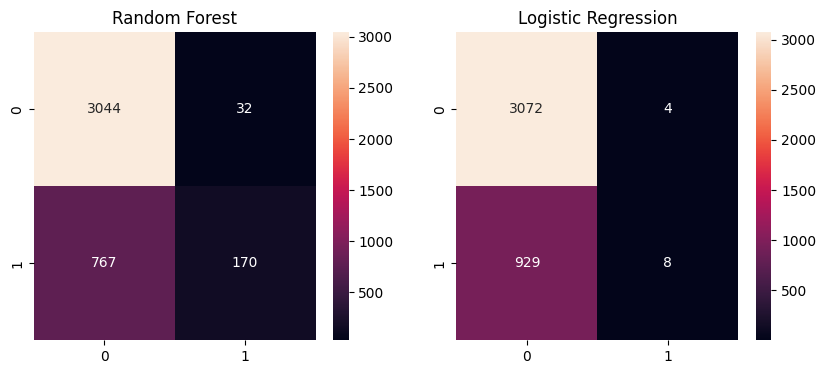

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

cm_rf = confusion_matrix(y_test_c, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", ax=axes[0])
axes[0].set_title("Random Forest")

cm_lr = confusion_matrix(y_test_c, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", ax=axes[1])
axes[1].set_title("Logistic Regression")

plt.show()

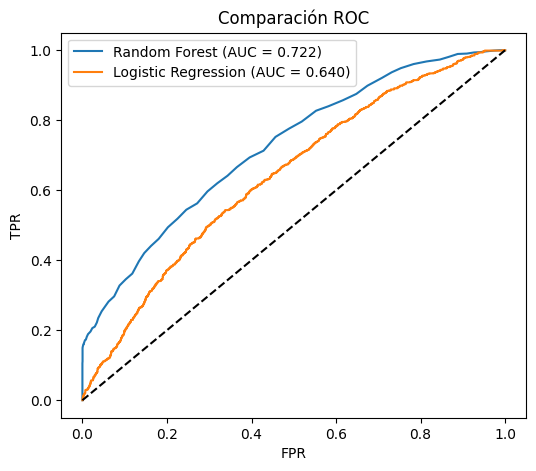

In [17]:
fpr_rf, tpr_rf, _ = roc_curve(y_test_c, y_proba_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test_c, y_proba_lr)

auc_rf = auc(fpr_rf, tpr_rf)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot([0,1],[0,1],"k--")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Comparación ROC")
plt.legend()
plt.show()

In [22]:
import pandas as pd
import yaml

with open("../config/config.yaml") as f:
    config = yaml.safe_load(f)

df_feat = pd.read_csv("../data/processed/datos_limpios.csv")

print("df_feat cargado:", df_feat.shape)

df_feat cargado: (20063, 34)


In [23]:
df_model = df_feat.copy()

df_model = df_model.drop(columns=[
    "Artist", "Track",
    "Stream", "Views", "Likes", "Comments"
], errors="ignore")

df_model = df_model.dropna()

In [24]:
from pycaret.classification import *

clf = setup(
    data=df_model,
    target="viral",
    session_id=42
)

,Description,Value
0,Session id,42
1,Target,viral
2,Target type,Binary
3,Original data shape,"(19093, 28)"
4,Transformed data shape,"(19093, 28)"
5,Transformed train set shape,"(13365, 28)"
6,Transformed test set shape,"(5728, 28)"
7,Numeric features,20
8,Categorical features,7
9,Preprocess,True


In [25]:
from pycaret.classification import load_model

final_model = load_model("best_pycaret_model")

print("Modelo cargado correctamente")

Transformation Pipeline and Model Successfully Loaded
Modelo cargado correctamente


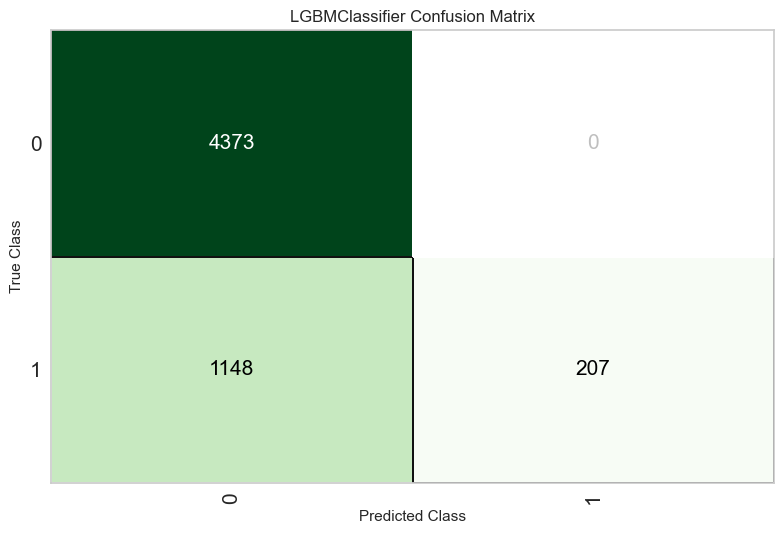

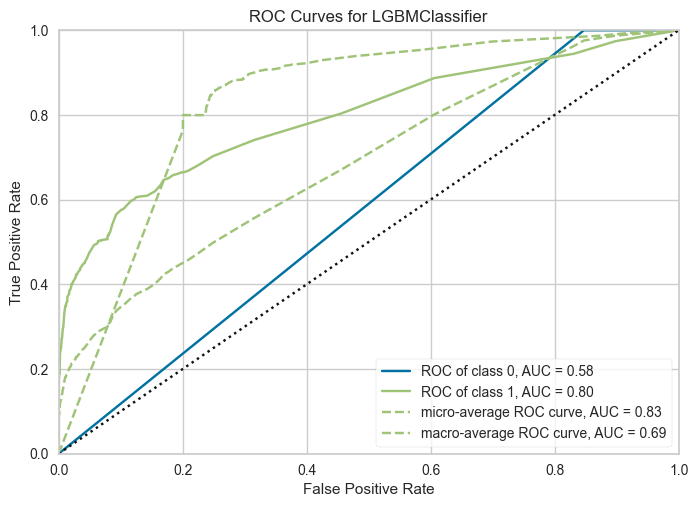

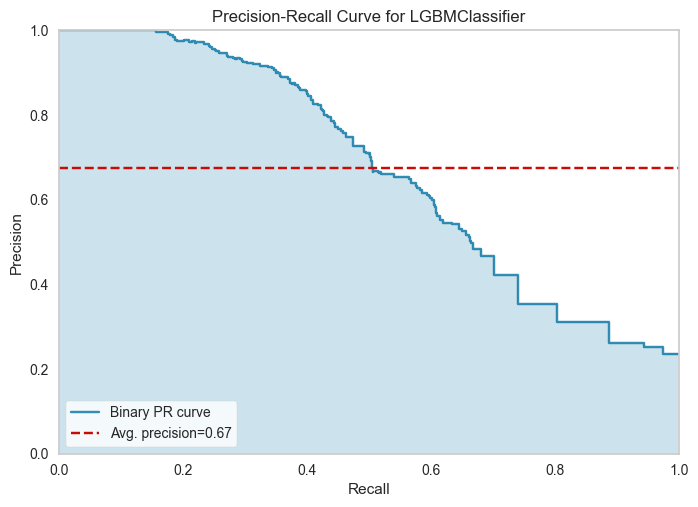

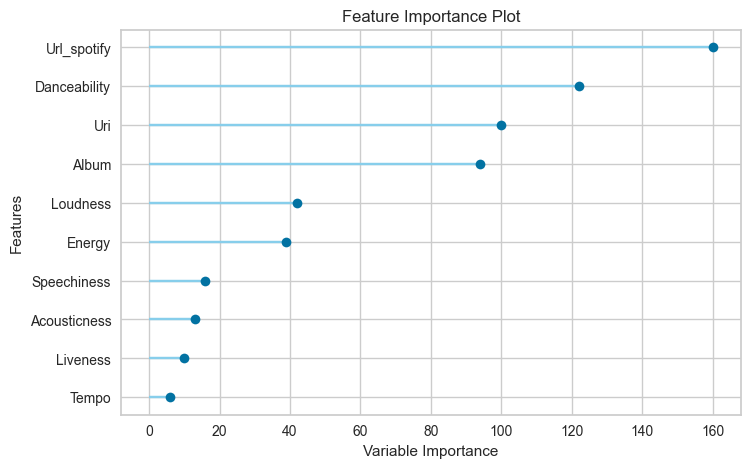

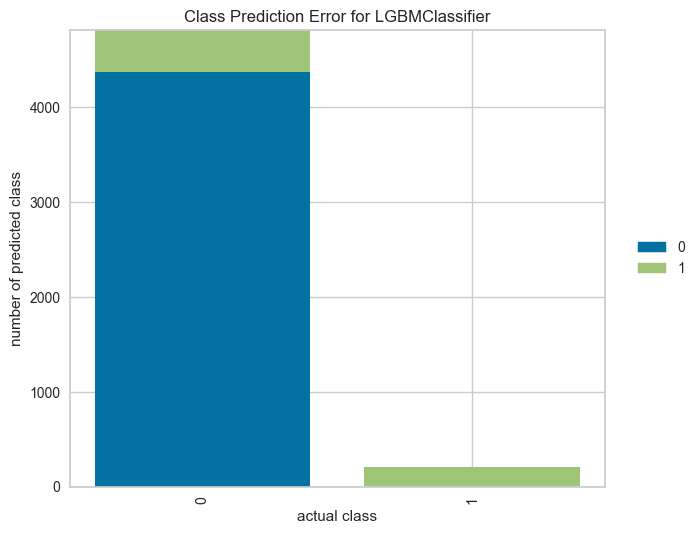

In [26]:
plot_model(final_model, plot='confusion_matrix')
plot_model(final_model, plot='auc')
plot_model(final_model, plot='pr')            # ← este reemplaza precision_recall
plot_model(final_model, plot='feature')
plot_model(final_model, plot='error')